# Search Algorithms: Romania Map and N-Queens

An original implementation (not copied from any specific codebase) of the main search algorithm families, using the same two examples the *Artificial Intelligence: A Modern Approach* textbook itself pairs them with:

- **Uninformed & informed search** — BFS, DFS, Uniform-Cost Search, Greedy Best-First, A\* — on the classic **Romania road map** (Arad → Bucharest)
- **Local search & genetic algorithms** — hill-climbing, random-restart hill-climbing, simulated annealing, and a genetic algorithm — on **N-Queens**

The Romania map data (city adjacency, road distances, and straight-line distances to Bucharest) is the same widely-published dataset used throughout the AI-education literature. Only `numpy` and `matplotlib` are required — no extra dependencies.

In [13]:
import random
import math
import heapq
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Part 1 — Uninformed & Informed Search: the Romania Map

The graph, road distances, and straight-line-distance-to-Bucharest heuristic below are the standard values for this example (Russell & Norvig, *AIMA*, Figs. 3.2 and 3.16).

In [2]:
romania_map = {
    'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
    'Zerind': {'Arad': 75, 'Oradea': 71},
    'Oradea': {'Zerind': 71, 'Sibiu': 151},
    'Sibiu': {'Arad': 140, 'Oradea': 151, 'Fagaras': 99, 'RimnicuVilcea': 80},
    'Timisoara': {'Arad': 118, 'Lugoj': 111},
    'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
    'Mehadia': {'Lugoj': 70, 'Drobeta': 75},
    'Drobeta': {'Mehadia': 75, 'Craiova': 120},
    'Craiova': {'Drobeta': 120, 'RimnicuVilcea': 146, 'Pitesti': 138},
    'RimnicuVilcea': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
    'Fagaras': {'Sibiu': 99, 'Bucharest': 211},
    'Pitesti': {'RimnicuVilcea': 97, 'Craiova': 138, 'Bucharest': 101},
    'Bucharest': {'Fagaras': 211, 'Pitesti': 101, 'Giurgiu': 90, 'Urziceni': 85},
    'Giurgiu': {'Bucharest': 90},
    'Urziceni': {'Bucharest': 85, 'Hirsova': 98, 'Vaslui': 142},
    'Hirsova': {'Urziceni': 98, 'Eforie': 86},
    'Eforie': {'Hirsova': 86},
    'Vaslui': {'Urziceni': 142, 'Iasi': 92},
    'Iasi': {'Vaslui': 92, 'Neamt': 87},
    'Neamt': {'Iasi': 87},
}

sld_to_bucharest = {
    'Arad': 366, 'Bucharest': 0, 'Craiova': 160, 'Drobeta': 242, 'Eforie': 161,
    'Fagaras': 176, 'Giurgiu': 77, 'Hirsova': 151, 'Iasi': 226, 'Lugoj': 244,
    'Mehadia': 241, 'Neamt': 234, 'Oradea': 380, 'Pitesti': 100, 'RimnicuVilcea': 193,
    'Sibiu': 253, 'Timisoara': 329, 'Urziceni': 80, 'Vaslui': 199, 'Zerind': 374,
}

# Approximate schematic (x, y) positions for plotting only -- not to geographic scale
positions = {
    'Oradea': (2, 8), 'Zerind': (2, 6.5), 'Arad': (1, 5), 'Sibiu': (4.5, 5),
    'Timisoara': (1, 3), 'Lugoj': (2.5, 2), 'Mehadia': (3, 1), 'Drobeta': (2.5, -0.5),
    'Craiova': (4.5, -1), 'RimnicuVilcea': (5, 3), 'Fagaras': (7, 5),
    'Pitesti': (6.5, 1), 'Bucharest': (8, -0.5), 'Giurgiu': (8, -2),
    'Urziceni': (10, 0), 'Hirsova': (12, -0.5), 'Eforie': (13, -2),
    'Vaslui': (11, 3), 'Iasi': (10.5, 5.5), 'Neamt': (9, 6.5),
}

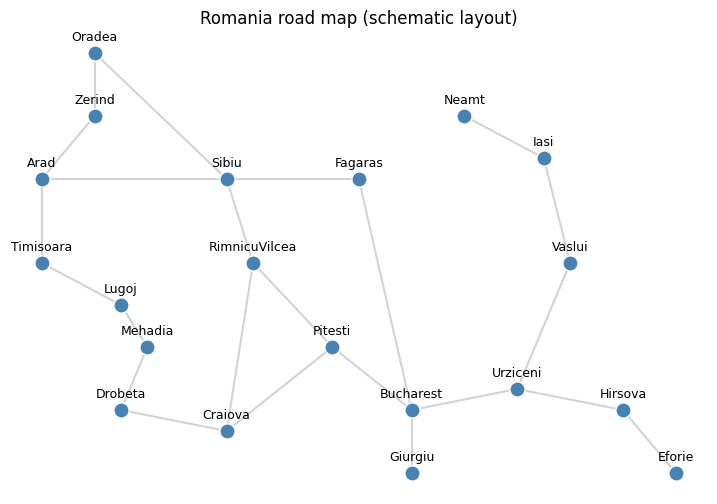

In [3]:
def draw_map(highlight_path=None, title='Romania'):
    fig, ax = plt.subplots(figsize=(9, 6))
    seen_edges = set()
    for city, nbrs in romania_map.items():
        for nbr in nbrs:
            edge = tuple(sorted([city, nbr]))
            if edge in seen_edges:
                continue
            seen_edges.add(edge)
            x1, y1 = positions[city]
            x2, y2 = positions[nbr]
            ax.plot([x1, x2], [y1, y2], color='lightgray', zorder=1, linewidth=1.5)
    if highlight_path:
        for i in range(len(highlight_path) - 1):
            x1, y1 = positions[highlight_path[i]]
            x2, y2 = positions[highlight_path[i + 1]]
            ax.plot([x1, x2], [y1, y2], color='crimson', zorder=2, linewidth=3)
    for city, (x, y) in positions.items():
        color = 'crimson' if highlight_path and city in highlight_path else 'steelblue'
        ax.scatter([x], [y], s=120, color=color, zorder=3, edgecolor='white')
        ax.text(x, y + 0.3, city, fontsize=9, ha='center')
    ax.set_title(title)
    ax.axis('off')
    plt.show()

draw_map(title='Romania road map (schematic layout)')

### The search algorithms

`best_first_search` is a single generic engine: give it a different priority function and it becomes UCS, greedy best-first, or A\*. BFS and DFS are structurally different (they don't use a priority queue at all), so they get their own small functions.

In [4]:
def best_first_search(start, goal, priority_fn):
    counter = 0
    frontier = [(priority_fn(start, 0), counter, start, 0)]
    came_from = {start: None}
    cost_so_far = {start: 0}
    order = []
    while frontier:
        _, _, node, g = heapq.heappop(frontier)
        if node in order:
            continue
        order.append(node)
        if node == goal:
            break
        for nbr, d in romania_map[node].items():
            new_g = g + d
            if nbr not in cost_so_far or new_g < cost_so_far[nbr]:
                cost_so_far[nbr] = new_g
                came_from[nbr] = node
                counter += 1
                heapq.heappush(frontier, (priority_fn(nbr, new_g), counter, nbr, new_g))
    path = [goal]
    while came_from[path[-1]] is not None:
        path.append(came_from[path[-1]])
    path.reverse()
    return path, order, cost_so_far.get(goal)

def bfs(start, goal):
    frontier = deque([start])
    came_from = {start: None}
    order = []
    while frontier:
        node = frontier.popleft()
        order.append(node)
        if node == goal:
            break
        for nbr in romania_map[node]:
            if nbr not in came_from:
                came_from[nbr] = node
                frontier.append(nbr)
    path = [goal]
    while came_from[path[-1]] is not None:
        path.append(came_from[path[-1]])
    path.reverse()
    cost = sum(romania_map[path[i]][path[i + 1]] for i in range(len(path) - 1))
    return path, order, cost

def dfs(start, goal):
    frontier = [start]
    came_from = {start: None}
    order = []
    visited = set()
    while frontier:
        node = frontier.pop()
        if node in visited:
            continue
        visited.add(node)
        order.append(node)
        if node == goal:
            break
        for nbr in romania_map[node]:
            if nbr not in visited and nbr not in came_from:
                came_from[nbr] = node
                frontier.append(nbr)
    path = [goal]
    while came_from[path[-1]] is not None:
        path.append(came_from[path[-1]])
    path.reverse()
    cost = sum(romania_map[path[i]][path[i + 1]] for i in range(len(path) - 1))
    return path, order, cost

In [5]:
start, goal = 'Arad', 'Bucharest'
algorithms = {
    'BFS':    lambda: bfs(start, goal),
    'DFS':    lambda: dfs(start, goal),
    'UCS':    lambda: best_first_search(start, goal, lambda n, g: g),
    'Greedy': lambda: best_first_search(start, goal, lambda n, g: sld_to_bucharest[n]),
    'A*':     lambda: best_first_search(start, goal, lambda n, g: g + sld_to_bucharest[n]),
}

solutions = {}
print(f"{'Algorithm':8s} {'Cost':>6s} {'Expanded':>9s}   Path")
for name, fn in algorithms.items():
    path, order, cost = fn()
    solutions[name] = (path, order, cost)
    print(f"{name:8s} {cost:6d} {len(order):9d}   {' -> '.join(path)}")

Algorithm   Cost  Expanded   Path
BFS         450         9   Arad -> Sibiu -> Fagaras -> Bucharest
DFS         733         8   Arad -> Timisoara -> Lugoj -> Mehadia -> Drobeta -> Craiova -> Pitesti -> Bucharest
UCS         418        13   Arad -> Sibiu -> RimnicuVilcea -> Pitesti -> Bucharest
Greedy      450         4   Arad -> Sibiu -> Fagaras -> Bucharest
A*          418         6   Arad -> Sibiu -> RimnicuVilcea -> Pitesti -> Bucharest


Notice: **Greedy best-first expands the fewest nodes but does not find the cheapest route** — it heads straight for Sibiu → Fagaras → Bucharest because Fagaras looks close to the goal in a straight line, ignoring that the road through Rimnicu Vilcea and Pitesti is actually shorter. **A\* expands more nodes than greedy but guarantees the optimal path**, because it also accounts for cost already paid. This is the single clearest illustration of why admissible heuristics matter.

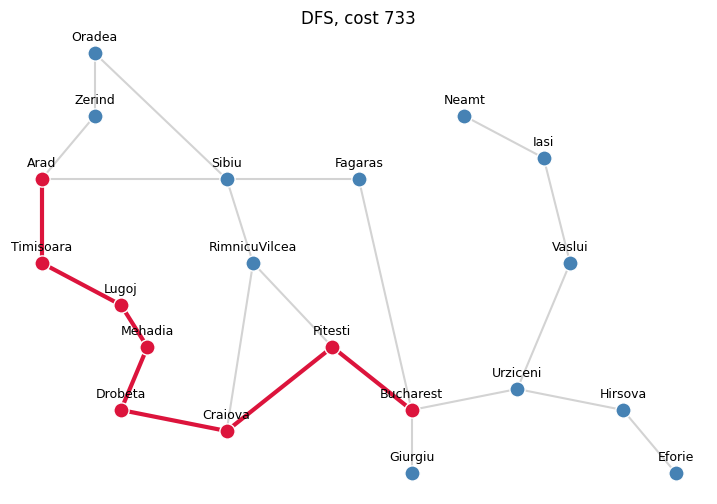

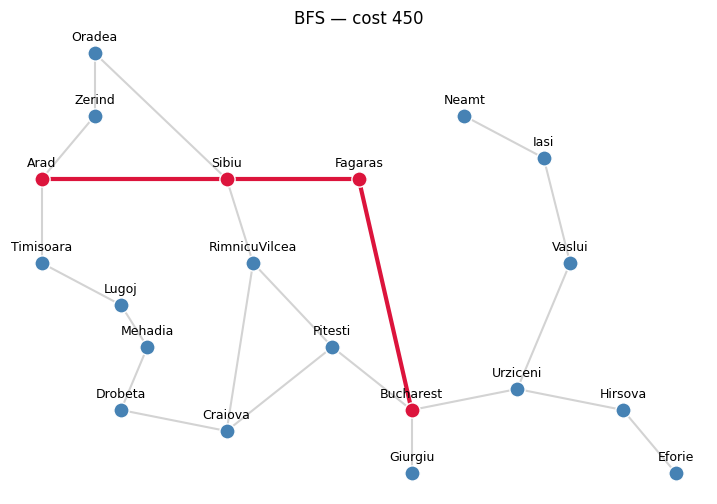

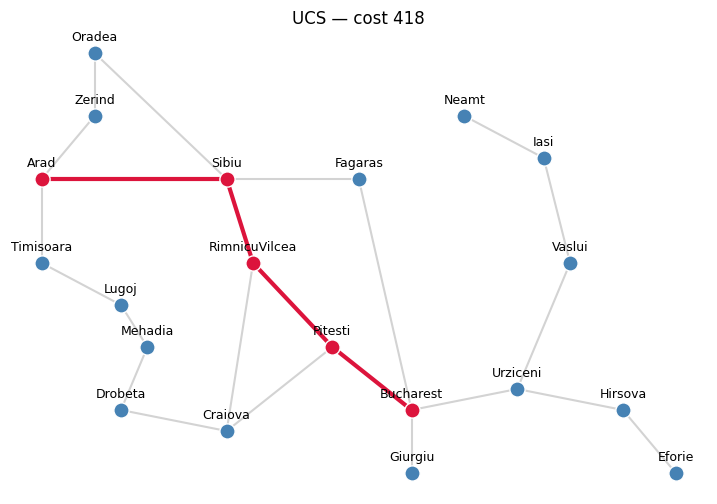

In [6]:
draw_map(solutions['DFS'][0], title=f"DFS, cost {solutions['DFS'][2]}")
draw_map(solutions['BFS'][0], title=f"BFS — cost {solutions['BFS'][2]}")
draw_map(solutions['UCS'][0], title=f"UCS — cost {solutions['UCS'][2]}")

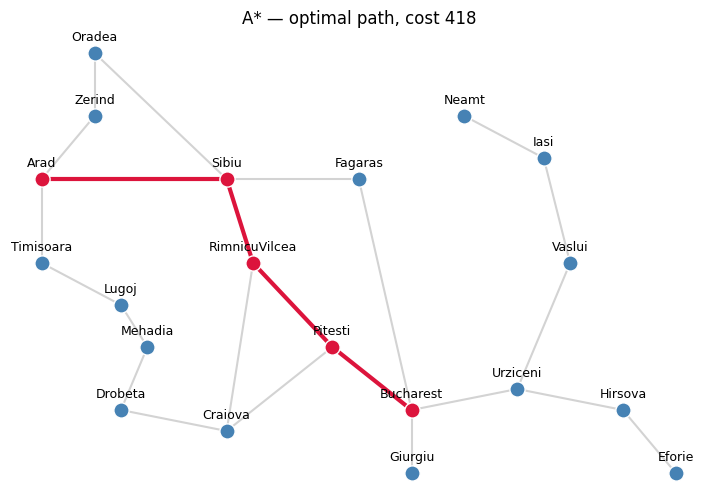

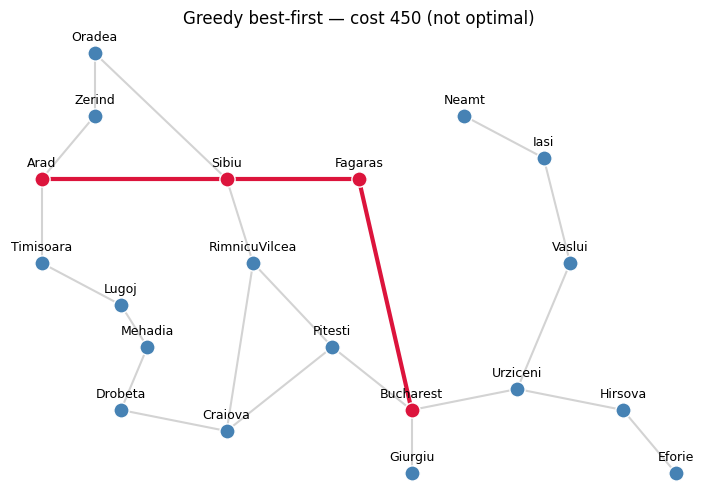

In [6]:
draw_map(solutions['A*'][0], title=f"A* — optimal path, cost {solutions['A*'][2]}")
draw_map(solutions['Greedy'][0], title=f"Greedy best-first — cost {solutions['Greedy'][2]} (not optimal)")

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import animation
from IPython.display import HTML

## Part 2 — Local Search & Genetic Algorithms: N-Queens

Place N queens on an N×N board so that no two attack each other. A state is a list of N column positions, one per row conflict-check via row/column/diagonal collisions — exactly AIMA's own local-search example, used here because (unlike Romania) it's a natural fit for hill-climbing, simulated annealing, and genetic algorithms.

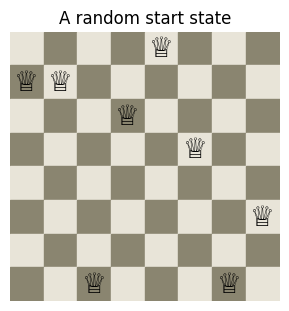

In [15]:
N = 8
MAX_CONFLICTS = N * (N - 1) // 2  # worst possible (=28 for N=8): fitness ceiling for the GA

def random_state():
    return [random.randrange(N) for _ in range(N)]

def conflicts(state):
    c = 0
    for i in range(N):
        for j in range(i + 1, N):
            if state[i] == state[j] or abs(state[i] - state[j]) == abs(i - j):
                c += 1
    return c

def draw_board(state, title=''):
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    for r in range(N):
        for c in range(N):
            color = '#e8e4d8' if (r + c) % 2 == 0 else '#8a8570'
            ax.add_patch(patches.Rectangle((c, N - 1 - r), 1, 1, color=color))
    for col, row in enumerate(state):
        ax.text(col + 0.5, N - 1 - row + 0.5, '\u2655', fontsize=20, ha='center', va='center')
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title or f'{conflicts(state)} conflicts')
    plt.show()

draw_board(random_state(), title='A random start state')

In [4]:
# def hill_climbing(state, allow_sideways=0, max_steps=1000):
#     state = state[:]
#     sideways = 0
#     for _ in range(max_steps):
#         cur = conflicts(state)
#         if cur == 0:
#             return state, True
#         best_val, best_moves = cur, []
#         for col in range(N):
#             orig = state[col]
#             for row in range(N):
#                 if row == orig:
#                     continue
#                 state[col] = row
#                 v = conflicts(state)
#                 if v < best_val:
#                     best_val, best_moves = v, [(col, row)]
#                 elif v == best_val and best_moves:
#                     best_moves.append((col, row))
#                 state[col] = orig
#         if not best_moves or best_val > cur:
#             return state, False  # stuck: local minimum, no improving or sideways move
#         if best_val == cur:
#             sideways += 1
#             if sideways > allow_sideways:
#                 return state, False
#         else:
#             sideways = 0
#         col, row = random.choice(best_moves)
#         state[col] = row
#     return state, conflicts(state) == 0
def hill_climbing(state, allow_sideways=0, max_steps=1000):
    state = state[:]

    sideways = 0

    # Store every state visited
    history = [state[:]]

    for _ in range(max_steps):

        cur = conflicts(state)

        # Solution found
        if cur == 0:
            return state, True, history

        best_val = cur
        best_moves = []

        # Examine all possible one-queen moves
        for col in range(N):

            orig = state[col]

            for row in range(N):

                if row == orig:
                    continue

                state[col] = row

                v = conflicts(state)

                if v < best_val:

                    best_val = v
                    best_moves = [(col, row)]

                elif v == best_val:

                    best_moves.append((col, row))

                state[col] = orig

        # No improving or allowed sideways move
        if not best_moves or best_val > cur:
            return state, False, history

        # Sideways move
        if best_val == cur:

            sideways += 1

            if sideways > allow_sideways:
                return state, False, history

        # Improvement
        else:
            sideways = 0

        # Randomly choose among equally good moves
        col, row = random.choice(best_moves)

        state[col] = row

        # Record the new state
        history.append(state[:])

    return state, conflicts(state) == 0, history

def random_restart_hill_climbing(
    max_restarts=100,
    allow_sideways=0,
    max_steps=1000
):

    # Complete history of all restarts
    history = []

    for attempt in range(max_restarts):

        # Generate a new random starting state
        initial_state = random_state()

        # Run hill climbing
        state, solved, hc_history = hill_climbing(
            initial_state,
            allow_sideways=allow_sideways,
            max_steps=max_steps
        )

        # Store information about this restart
        history.append({
            "restart": attempt + 1,
            "initial_state": initial_state[:],
            "history": hc_history,
            "final_state": state[:],
            "solved": solved
        })

        # Stop if solution found
        if solved:

            return (
                state,
                True,
                attempt + 1,
                history
            )

    # No solution found
    return (
        state,
        False,
        max_restarts,
        history
    )


# ============================================================
# Simulated Annealing
# ============================================================

def simulated_annealing(
    state,
    max_steps=10000,
    initial_temperature=1.0,
    final_temperature=0.01
):

    state = state[:]

    # Store all accepted states
    history = [state[:]]

    # Store additional information about every move
    move_history = []

    for t in range(1, max_steps):

        # ----------------------------------------------------
        # Temperature
        # ----------------------------------------------------

        T = (
            initial_temperature
            + (final_temperature - initial_temperature)
            * (t / max_steps)
        )

        T = max(final_temperature, T)


        # ----------------------------------------------------
        # Current objective
        # ----------------------------------------------------

        cur = conflicts(state)

        if cur == 0:

            return (
                state,
                True,
                history,
                move_history
            )


        # ----------------------------------------------------
        # Generate a random neighboring state
        # ----------------------------------------------------

        col = random.randrange(N)
        row = random.randrange(N)

        orig = state[col]

        state[col] = row

        new_conflicts = conflicts(state)

        delta = cur - new_conflicts

        # delta > 0  -> improvement
        # delta = 0  -> same
        # delta < 0  -> worse


        # ----------------------------------------------------
        # Decide whether to accept the move
        # ----------------------------------------------------

        if delta > 0:

            # Always accept improvement
            accepted = True

        else:

            # For equal or worse moves:
            #
            # P(accept) = exp(delta / T)
            #
            # delta <= 0
            # therefore probability <= 1

            probability = math.exp(
                delta / T
            )

            accepted = (
                random.random() < probability
            )


        # ----------------------------------------------------
        # Accept or reject
        # ----------------------------------------------------

        if accepted:

            # Keep the new state
            history.append(state[:])

            move_history.append({
                "step": t,
                "from_state": (
                    history[-2][:]
                    if len(history) >= 2
                    else None
                ),
                "to_state": state[:],
                "old_conflicts": cur,
                "new_conflicts": new_conflicts,
                "delta": delta,
                "temperature": T,
                "accepted": True
            })

        else:

            # Restore original state
            state[col] = orig

            move_history.append({
                "step": t,
                "from_state": state[:],
                "to_state": None,
                "old_conflicts": cur,
                "new_conflicts": new_conflicts,
                "delta": delta,
                "temperature": T,
                "accepted": False
            })


    # --------------------------------------------------------
    # Maximum number of iterations reached
    # --------------------------------------------------------

    return (
        state,
        conflicts(state) == 0,
        history,
        move_history
    )

# def random_restart_hill_climbing(max_restarts=100, allow_sideways=0):
#     for attempt in range(max_restarts):
#         state, solved = hill_climbing(random_state(), allow_sideways=allow_sideways)
#         if solved:
#             return state, True, attempt + 1
#     return state, False, max_restarts

# def simulated_annealing(state, max_steps=10000):
#     state = state[:]
#     for t in range(1, max_steps):
#         T = max(0.01, 1 - t / max_steps)
#         cur = conflicts(state)
#         if cur == 0:
#             return state, True
#         col, row = random.randrange(N), random.randrange(N)
#         orig = state[col]
#         state[col] = row
#         delta = cur - conflicts(state)  # positive = improvement
#         if delta <= 0 and random.random() >= math.exp(delta / T):
#             state[col] = orig  # reject the move
#     return state, conflicts(state) == 0

In [10]:
def random_state(N=8):
    """
    Generate a random N-Queens state.

    state[col] = row
    means that the queen in column `col`
    is placed in row `row`.
    """
    return [
        random.randrange(N)
        for _ in range(N)
    ]

In [11]:
def genetic_algorithm(
    pop_size=100,
    generations=1000,
    mutation_rate=0.15,
    elite=4
):

    # --------------------------------------------------------
    # Fitness function
    #
    # MAX_CONFLICTS = maximum possible number of conflicts
    #
    # Therefore:
    #
    #   more conflicts  -> lower fitness
    #   fewer conflicts  -> higher fitness
    #   zero conflicts  -> MAX_CONFLICTS fitness
    # --------------------------------------------------------

    def fitness(s):
        return MAX_CONFLICTS - conflicts(s)


    # --------------------------------------------------------
    # Initial population
    # --------------------------------------------------------

    population = [
        random_state()
        for _ in range(pop_size)
    ]


    # --------------------------------------------------------
    # Store information about every generation
    # --------------------------------------------------------

    history = []


    # ========================================================
    # Main genetic algorithm
    # ========================================================

    for gen in range(generations):


        # ----------------------------------------------------
        # Rank population by fitness
        # ----------------------------------------------------

        ranked = sorted(
            population,
            key=lambda s: -fitness(s)
        )


        # ----------------------------------------------------
        # Best individual
        # ----------------------------------------------------

        best = ranked[0]

        best_fitness = fitness(best)

        best_conflicts = conflicts(best)


        # ----------------------------------------------------
        # Save generation information
        # ----------------------------------------------------

        history.append({
            "generation": gen,
            "best_state": best[:],
            "best_fitness": best_fitness,
            "best_conflicts": best_conflicts,
            "population": [
                s[:] for s in population
            ]
        })


        # ----------------------------------------------------
        # Check whether solution found
        # ----------------------------------------------------

        if best_fitness == MAX_CONFLICTS:

            return (
                best,
                True,
                gen,
                history
            )


        # ----------------------------------------------------
        # Selection weights
        #
        # Better individuals receive larger probability
        # of being selected as parents.
        # ----------------------------------------------------

        weights = [
            fitness(s) + 1
            for s in ranked
        ]


        # ----------------------------------------------------
        # Elitism
        #
        # Keep the best individuals unchanged.
        # ----------------------------------------------------

        new_pop = [
            s[:]
            for s in ranked[:elite]
        ]


        # ====================================================
        # Create children
        # ====================================================

        while len(new_pop) < pop_size:


            # ------------------------------------------------
            # Select two parents
            # ------------------------------------------------

            p1, p2 = random.choices(
                ranked,
                weights=weights,
                k=2
            )


            # ------------------------------------------------
            # One-point crossover
            # ------------------------------------------------

            cut = random.randrange(1, N)

            child = (
                p1[:cut]
                +
                p2[cut:]
            )


            # ------------------------------------------------
            # Mutation
            # ------------------------------------------------

            if random.random() < mutation_rate:

                col = random.randrange(N)
                row = random.randrange(N)

                child[col] = row


            # ------------------------------------------------
            # Add child
            # ------------------------------------------------

            new_pop.append(child)


        # ----------------------------------------------------
        # Replace old population
        # ----------------------------------------------------

        population = new_pop


    # ========================================================
    # Maximum number of generations reached
    # ========================================================

    best = max(
        population,
        key=fitness
    )

    solved = (
        fitness(best) == MAX_CONFLICTS
    )


    return (
        best,
        solved,
        generations,
        history
    )
# def genetic_algorithm(pop_size=100, generations=1000, mutation_rate=0.15, elite=4):
#     def fitness(s):
#         return MAX_CONFLICTS - conflicts(s)
#     population = [random_state() for _ in range(pop_size)]
#     for gen in range(generations):
#         ranked = sorted(population, key=lambda s: -fitness(s))
#         if fitness(ranked[0]) == MAX_CONFLICTS:
#             return ranked[0], True, gen
#         weights = [fitness(s) + 1 for s in ranked]
#         new_pop = ranked[:elite]  # elitism: carry the best forward unchanged
#         while len(new_pop) < pop_size:
#             p1, p2 = random.choices(ranked, weights=weights, k=2)
#             cut = random.randrange(1, N)
#             child = p1[:cut] + p2[cut:]
#             if random.random() < mutation_rate:
#                 child[random.randrange(N)] = random.randrange(N)
#             new_pop.append(child)
#         population = new_pop
#     best = max(population, key=fitness)
#     return best, fitness(best) == MAX_CONFLICTS, generations

### Comparing the four methods

Plain steepest-ascent hill-climbing gets stuck on local minima (and flat plateaus) far more often than the other three — that's not a bug, it's the entire reason random-restarts, simulated annealing, and population-based search exist.

In [10]:
random.seed(0)
trials = 30

plain_hc = [hill_climbing(random_state()) for _ in range(trials)]
plain_rate = sum(ok for _, ok in plain_hc) / trials

sideways_hc = [hill_climbing(random_state(), allow_sideways=30) for _ in range(trials)]
sideways_rate = sum(ok for _, ok in sideways_hc) / trials

sa_trials = [simulated_annealing(random_state()) for _ in range(trials)]
sa_rate = sum(ok for _, ok in sa_trials) / trials

print(f"{'Method':32s} {'Success rate':>12s}")
print(f"{'Hill-climbing (no sideways)':32s} {plain_rate:12.0%}")
print(f"{'Hill-climbing (+ sideways moves)':32s} {sideways_rate:12.0%}")
print(f"{'Simulated annealing':32s} {sa_rate:12.0%}")

restart_state, restart_ok, restarts_used = random_restart_hill_climbing()
print(f"{'Random-restart hill-climbing':32s} {'100% (by construction)':>12s}  -- solved after {restarts_used} restart(s) this run")

ga_state, ga_ok, ga_gen = genetic_algorithm()
print(f"{'Genetic algorithm':32s} {'solved' if ga_ok else 'not solved':>12s}  -- generation {ga_gen}")

Method                           Success rate
Hill-climbing (no sideways)               10%
Hill-climbing (+ sideways moves)          10%
Simulated annealing                      100%
Random-restart hill-climbing     100% (by construction)  -- solved after 8 restart(s) this run
Genetic algorithm                      solved  -- generation 9


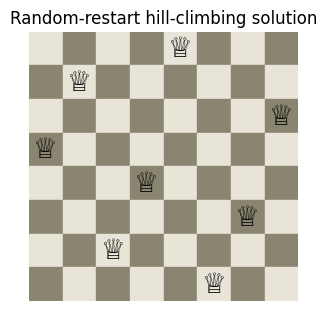

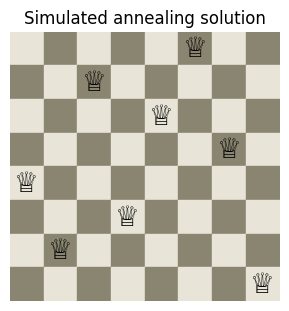

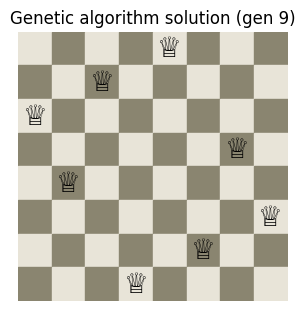

In [11]:
draw_board(restart_state, title='Random-restart hill-climbing solution')
draw_board(sa_trials[0][0] if sa_trials[0][1] else simulated_annealing(random_state())[0], title='Simulated annealing solution')
draw_board(ga_state, title=f"Genetic algorithm solution (gen {ga_gen})" if ga_ok else 'Genetic algorithm: best attempt')

## Discussion

- Greedy best-first expanded the fewest nodes on the Romania map but returned a worse path than A\*. Under what condition on the heuristic is A\* *guaranteed* to be optimal? Does the straight-line-distance-to-Bucharest heuristic satisfy it?
- Plain hill-climbing fails on a large fraction of random N-Queens starts. Where exactly does it get stuck — a true local minimum, or a flat plateau? How would you tell the difference from the numbers this notebook prints?
- Random-restart hill-climbing eventually succeeds "by construction." Is that a fair comparison against simulated annealing and the genetic algorithm, which are allowed to fail within their fixed step/generation budget? What would a fairer comparison measure instead (e.g. total states explored across all restarts)?
- The genetic algorithm's crossover here is a single cut point over an arbitrary column order. Does that crossover actually preserve useful "building blocks" of a partial solution for N-Queens the way it would for, say, a bit-string optimization problem?

### Try it yourself
- Increase `N` to 20 or 50. Which methods keep working, and which ones degrade first?
- Add a `max_sideways` sweep for hill-climbing (0, 10, 30, 100) and plot success rate vs. sideways-move budget.
- Replace A\*'s heuristic with a deliberately *inadmissible* one (e.g. `2 * sld_to_bucharest[n]`) on the Romania map. Does it still find the optimal path every time, sometimes, or never?

In [23]:
best, solved, generation, history = genetic_algorithm(
    pop_size=100,
    generations=1000,
    mutation_rate=0.15,
    elite=4
)

print("Solved:", solved)
print("Generation:", generation)
print("Conflicts:", conflicts(best))
print("Best state:", best)

Solved: True
Generation: 17
Conflicts: 0
Best state: [5, 2, 4, 7, 0, 3, 1, 6]


In [24]:
def animate_genetic_algorithm(history, title="Genetic Algorithm"):

    fig, ax = plt.subplots(figsize=(4, 4))


    def draw(i):

        ax.clear()

        # ----------------------------------------------------
        # Current generation
        # ----------------------------------------------------

        record = history[i]

        state = record["best_state"]

        generation = record["generation"]

        conflict_count = record["best_conflicts"]

        fitness_value = record["best_fitness"]


        # ----------------------------------------------------
        # Draw chessboard
        # ----------------------------------------------------

        for r in range(N):

            for c in range(N):

                color = (
                    '#e8e4d8'
                    if (r + c) % 2 == 0
                    else '#8a8570'
                )

                ax.add_patch(
                    patches.Rectangle(
                        (c, N - 1 - r),
                        1,
                        1,
                        color=color
                    )
                )


        # ----------------------------------------------------
        # Draw queens
        # ----------------------------------------------------

        for col, row in enumerate(state):

            ax.text(
                col + 0.5,
                N - 1 - row + 0.5,
                '\u2655',
                fontsize=20,
                ha='center',
                va='center'
            )


        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_xlim(0, N)
        ax.set_ylim(0, N)
        ax.set_aspect('equal')
        ax.axis('off')

        ax.set_title(
            f"{title}\n"
            f"Generation: {generation}\n"
            f"Conflicts: {conflict_count}   "
            f"Fitness: {fitness_value}"
        )


    def update(i):

        draw(i)

        return []


    anim = animation.FuncAnimation(
        fig,
        update,
        frames=len(history),
        interval=150,
        blit=False
    )


    plt.close(fig)

    return HTML(
        anim.to_jshtml()
    )

In [25]:
animate_genetic_algorithm(
    history,
    "N-Queens Genetic Algorithm"
)

In [28]:
initial_state = random_state()

hc_state, hc_solved, hc_history = hill_climbing(
    initial_state,
    allow_sideways=10,
    max_steps=1000
)

print("Solved:", hc_solved)
print("Moves:", len(hc_history) - 1)
print("Final conflicts:", conflicts(hc_state))

Solved: True
Moves: 5
Final conflicts: 0


In [29]:
def animate_search(history, title="Search", N=8):
    fig, ax = plt.subplots(figsize=(4, 4))

    def draw(i):
        ax.clear()

        state = history[i]

        for r in range(N):
            for c in range(N):
                color = (
                    '#e8e4d8'
                    if (r + c) % 2 == 0
                    else '#8a8570'
                )

                ax.add_patch(
                    patches.Rectangle(
                        (c, N - 1 - r),
                        1,
                        1,
                        color=color
                    )
                )

        for col, row in enumerate(state):
            ax.text(
                col + 0.5,
                N - 1 - row + 0.5,
                '\u2655',
                fontsize=20,
                ha='center',
                va='center'
            )

        ax.set_xlim(0, N)
        ax.set_ylim(0, N)
        ax.set_aspect('equal')
        ax.axis('off')

        ax.set_title(
            f"{title}\n"
            f"Move {i}/{len(history)-1}   "
            f"Conflicts: {conflicts(state)}"
        )

    anim = animation.FuncAnimation(
        fig,
        draw,
        frames=len(history),
        interval=500,
        blit=False
    )

    plt.close(fig)

    return HTML(anim.to_jshtml())

In [30]:
animate_search(
    hc_history,
    "Hill Climbing"
)

In [31]:
initial_state = random_state()

sa_state, sa_solved, sa_history, sa_moves = simulated_annealing(
    initial_state,
    max_steps=10000
)

print("Solved:", sa_solved)
print("Accepted moves:", len(sa_history) - 1)
print("Final conflicts:", conflicts(sa_state))

Solved: True
Accepted moves: 2387
Final conflicts: 0


In [33]:
animate_search(
    sa_history,
    "Simulated Annealing"
)

KeyboardInterrupt: 